# Problem Statement

# STEP 1. Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


# STEP 2: Load Dataset

In [3]:
df = pd.read_csv("healthcare_patient_journey.csv")
df.head()


,patient_id,age,gender,chronic_condition,admission_type,department,wait_time_min,length_of_stay_days,procedures_count,medication_count,complications,discharge_status,readmitted_30d,total_cost_€,satisfaction_score
0,1,69,male,0,scheduled,Neurology,41,2,0,3,1,referred,1,1440,2
1,2,38,male,0,emergency,Oncology,17,3,1,2,0,recovered,0,2060,3
2,3,81,male,0,scheduled,Neurology,40,2,3,2,0,recovered,0,2110,3
3,4,67,female,1,emergency,ER,7,4,5,9,0,recovered,0,4070,3
4,5,88,male,1,emergency,Cardiology,34,3,7,5,0,recovered,1,3800,3


# STEP 3 : Understanding Data

In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           3000 non-null   int64 
 1   age                  3000 non-null   int64 
 2   gender               3000 non-null   object
 3   chronic_condition    3000 non-null   int64 
 4   admission_type       3000 non-null   object
 5   department           3000 non-null   object
 6   wait_time_min        3000 non-null   int64 
 7   length_of_stay_days  3000 non-null   int64 
 8   procedures_count     3000 non-null   int64 
 9   medication_count     3000 non-null   int64 
 10  complications        3000 non-null   int64 
 11  discharge_status     3000 non-null   object
 12  readmitted_30d       3000 non-null   int64 
 13  total_cost_€         3000 non-null   int64 
 14  satisfaction_score   3000 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 351.7+ KB


patient_id             0
age                    0
gender                 0
chronic_condition      0
admission_type         0
department             0
wait_time_min          0
length_of_stay_days    0
procedures_count       0
medication_count       0
complications          0
discharge_status       0
readmitted_30d         0
total_cost_€           0
satisfaction_score     0
dtype: int64

### Inference

# STEP 4: Exploratory Data Analysis (EDA)

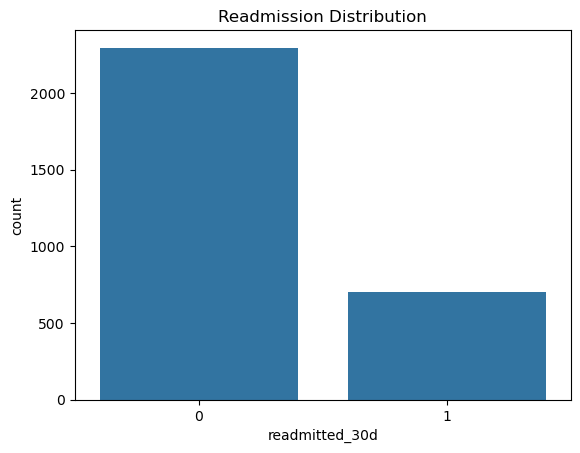

In [22]:
sns.countplot(x='readmitted_30d', data=df)
plt.title("Readmission Distribution")
plt.show()


### Inference

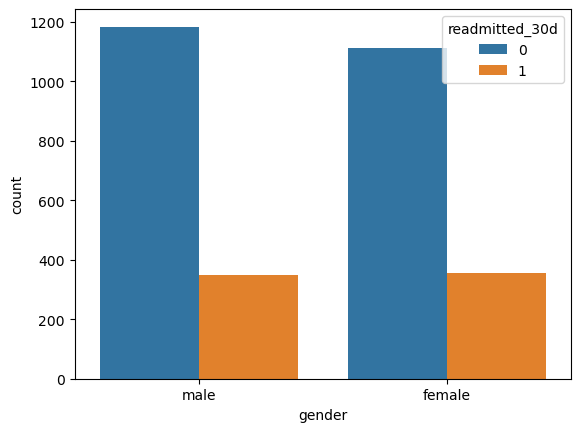

In [6]:
sns.countplot(x='gender', hue='readmitted_30d', data=df)
plt.show()


### Inference

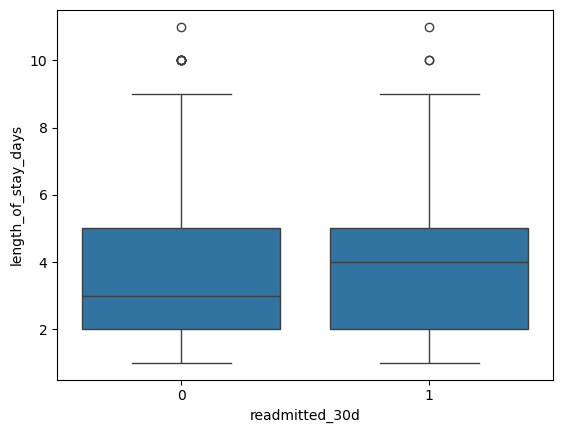

In [7]:
sns.boxplot(x='readmitted_30d', y='length_of_stay_days', data=df)
plt.show()


### Inference

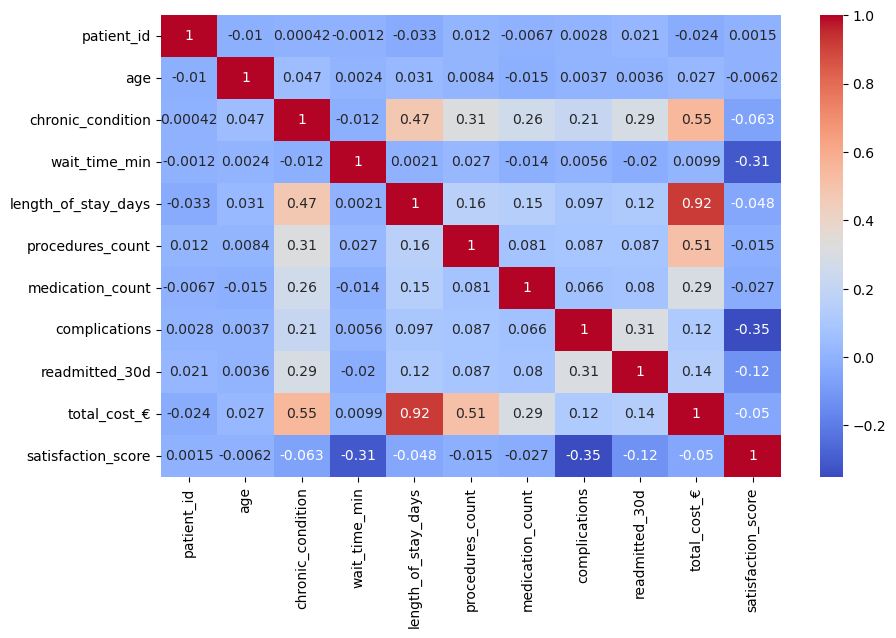

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


# STEP 5: Feature Engineering – Inference

In [9]:
df['cost_per_day'] = df['total_cost_€'] / df['length_of_stay_days']
df['high_medication_flag'] = np.where(df['medication_count'] > df['medication_count'].median(), 1, 0)


# STEP 6 : Encoding Categorical Variables – Inference

In [10]:
categorical_cols = ['gender','chronic_condition','admission_type','department','discharge_status','complications']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


# STEP 7: Define Features & Target – Inference

In [11]:
X = df.drop(['patient_id','readmitted_30d'], axis=1)
y = df['readmitted_30d']


# STEP 8: Train-Test Split – Inference

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# STEP 9: Feature Scaling – Inference

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# STEP 10: Logistic Regression – Inference

In [14]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.79      0.95      0.86       450
           1       0.60      0.23      0.34       150

    accuracy                           0.77       600
   macro avg       0.70      0.59      0.60       600
weighted avg       0.74      0.77      0.73       600



In [15]:
confusion_matrix(y_test, y_pred_log)


array([[427,  23],
       [115,  35]])

# STEP 11: Random Forest – Inference

In [16]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.78      0.94      0.85       450
           1       0.53      0.19      0.28       150

    accuracy                           0.76       600
   macro avg       0.65      0.57      0.57       600
weighted avg       0.72      0.76      0.71       600



# STEP 12: Feature Importance – Inference

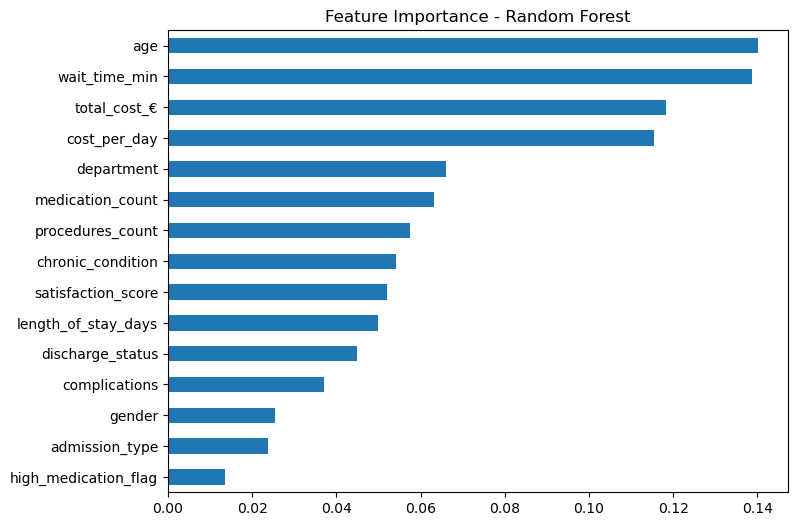

In [17]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.show()


# STEP 13: ROC Curve – Inference

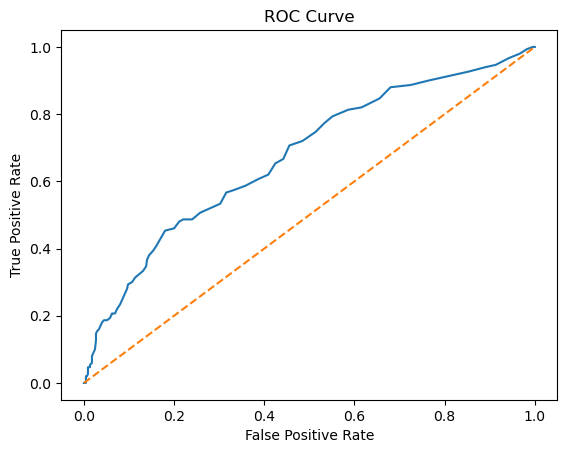

np.float64(0.6741777777777778)

In [18]:
y_prob = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

roc_auc_score(y_test, y_prob)


# STEP 14: K-Means Clustering – Inference

In [19]:
cluster_features = df[['length_of_stay_days','medication_count','procedures_count','total_cost_€']]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(cluster_scaled)


# STEP 15: Cluster Analysis – Inference

In [20]:
df.groupby('cluster').mean(numeric_only=True)


,patient_id,age,gender,chronic_condition,admission_type,department,wait_time_min,length_of_stay_days,procedures_count,medication_count,complications,discharge_status,readmitted_30d,total_cost_€,satisfaction_score,cost_per_day,high_medication_flag
cluster,,,,,,,,,,,,,,,,,
0,1524.218543,52.678146,0.500662,0.449007,0.406623,2.042384,32.712583,3.344371,2.050331,5.340397,0.174834,0.174834,0.259603,2744.781457,2.798675,970.053138,0.932450
1,1471.492130,53.794334,0.524659,0.708290,0.413431,2.012592,33.614900,5.625393,3.530955,3.433368,0.206716,0.206716,0.291710,3988.835257,2.754460,743.528742,0.435467
2,1508.036378,52.721362,0.506966,0.157121,0.423375,2.001548,33.472136,2.104489,1.852941,2.252322,0.117647,0.117647,0.178019,1890.441176,2.841331,1066.946207,0.139319


# Final Inference: